In [1]:
# 🔧 Environment Setup and Imports
import os
import sys
import shutil
import random
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
import yaml
import torch
import subprocess
from pathlib import Path
import warnings
import seaborn as sns
from datetime import datetime
import time

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Display system information
print("🔧 System Information:")
print("=" * 50)
print(f"🐍 Python version: {sys.version}")
print(f"🔥 PyTorch version: {torch.__version__}")
print(f"🖥️  CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"🚀 GPU: {torch.cuda.get_device_name(0)}")
    print(f"💾 GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    device = "cuda"
else:
    print("⚠️  Using CPU for training (GPU recommended for faster training)")
    device = "cpu"

print(f"🎯 Training device: {device}")
print("=" * 50)


🔧 System Information:
🐍 Python version: 3.11.13 (main, Jun  5 2025, 08:21:08) [Clang 14.0.6 ]
🔥 PyTorch version: 2.7.1
🖥️  CUDA available: False
⚠️  Using CPU for training (GPU recommended for faster training)
🎯 Training device: cpu


In [2]:
# 📦 YOLOv5 Setup
print("📦 Setting up YOLOv5 environment...")

# Ensure YOLOv5 is available
if not os.path.exists('yolov5'):
    print("❌ YOLOv5 directory not found!")
    print("Please ensure you have the YOLOv5 repository in your project directory")
    sys.exit(1)
else:
    print("✅ YOLOv5 repository found")

# Add YOLOv5 to Python path
sys.path.append('yolov5')

# Change to project directory for relative paths
os.chdir('/Users/ryoo/Desktop/usc_hackathon/Road-Damage-Detection')
print(f"📁 Working directory: {os.getcwd()}")

# Check for pretrained weights
weights_available = []
for weight in ['yolov5n.pt', 'yolov5s.pt', 'yolov5m.pt', 'yolov5l.pt', 'yolov5x.pt']:
    if os.path.exists(weight) or os.path.exists(f'yolov5/{weight}'):
        weights_available.append(weight)

print(f"🏋️  Available pretrained weights: {weights_available if weights_available else 'None (will download during training)'}")


📦 Setting up YOLOv5 environment...
✅ YOLOv5 repository found
📁 Working directory: /Users/ryoo/Desktop/usc_hackathon/Road-Damage-Detection
🏋️  Available pretrained weights: ['yolov5s.pt']


In [3]:
# 📊 Dataset Verification and Statistics
def verify_road_damage_dataset(data_path="yolo_dataset/data.yaml"):
    """Verify the road damage dataset structure and display statistics"""
    print("📊 Verifying Road Damage Dataset...")
    print("=" * 60)
    
    if not os.path.exists(data_path):
        raise FileNotFoundError(f"Dataset configuration not found: {data_path}")
    
    # Load dataset configuration
    with open(data_path, 'r') as f:
        data_config = yaml.safe_load(f)
    
    print(f"📁 Dataset path: {data_config['path']}")
    print(f"🏷️  Number of classes: {data_config['nc']}")
    print(f"📋 Class names: {', '.join(data_config['names'])}")
    print()
    
    # Class mapping
    class_mapping = {
        0: "Pothole",
        1: "Alligator Crack", 
        2: "Transverse Crack",
        3: "Longitudinal Crack"
    }
    
    print("🎯 Class Mapping:")
    for i, name in class_mapping.items():
        print(f"   Class {i}: {name}")
    print()
    
    # Verify dataset splits and collect statistics
    base_path = Path(data_config['path'])
    dataset_stats = {
        'total_images': 0,
        'total_labels': 0,
        'class_counts': [0] * data_config['nc'],
        'splits': {}
    }
    
    for split in ['train', 'val', 'test']:
        images_dir = base_path / f"{split}/images"
        labels_dir = base_path / f"{split}/labels"
        
        if not images_dir.exists():
            print(f"⚠️  Images directory not found: {images_dir}")
            continue
        if not labels_dir.exists():
            print(f"⚠️  Labels directory not found: {labels_dir}")
            continue
        
        # Count images and labels
        image_files = list(images_dir.glob("*.jpg")) + list(images_dir.glob("*.png"))
        label_files = list(labels_dir.glob("*.txt"))
        
        image_count = len(image_files)
        label_count = len(label_files)
        
        print(f"📸 {split.capitalize()} Split:")
        print(f"   Images: {image_count:,}")
        print(f"   Labels: {label_count:,}")
        
        # Count annotations per class
        split_class_counts = [0] * data_config['nc']
        total_annotations = 0
        
        for label_file in label_files:
            try:
                with open(label_file, 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            class_id = int(parts[0])
                            if 0 <= class_id < data_config['nc']:
                                split_class_counts[class_id] += 1
                                total_annotations += 1
            except Exception as e:
                print(f"   ⚠️  Error reading {label_file}: {e}")
        
        print(f"   Annotations: {total_annotations:,}")
        print(f"   Avg annotations per image: {total_annotations/max(image_count,1):.2f}")
        
        # Update global statistics
        dataset_stats['total_images'] += image_count
        dataset_stats['total_labels'] += total_annotations
        for i in range(data_config['nc']):
            dataset_stats['class_counts'][i] += split_class_counts[i]
        
        dataset_stats['splits'][split] = {
            'images': image_count,
            'annotations': total_annotations,
            'class_counts': split_class_counts
        }
        print()
    
    # Display overall statistics
    print("📈 Overall Dataset Statistics:")
    print("=" * 40)
    print(f"📸 Total images: {dataset_stats['total_images']:,}")
    print(f"📦 Total annotations: {dataset_stats['total_labels']:,}")
    print(f"📊 Avg annotations per image: {dataset_stats['total_labels']/max(dataset_stats['total_images'],1):.2f}")
    print()
    
    print("🏷️  Class Distribution:")
    total_annotations = sum(dataset_stats['class_counts'])
    for i, (class_name, count) in enumerate(zip(class_mapping.values(), dataset_stats['class_counts'])):
        percentage = (count / max(total_annotations, 1)) * 100
        print(f"   {class_name}: {count:,} ({percentage:.1f}%)")
    
    print("\n✅ Dataset verification complete!")
    return data_config, dataset_stats

# Run dataset verification
data_config, dataset_stats = verify_road_damage_dataset()


📊 Verifying Road Damage Dataset...
📁 Dataset path: /Users/ryoo/Desktop/usc_hackathon/Road-Damage-Detection/yolo_dataset
🏷️  Number of classes: 4
📋 Class names: Pothole, Alligator Crack, Transverse Crack, Longitudinal Crack

🎯 Class Mapping:
   Class 0: Pothole
   Class 1: Alligator Crack
   Class 2: Transverse Crack
   Class 3: Longitudinal Crack

📸 Train Split:
   Images: 10,092
   Labels: 10,092
   Annotations: 27,049
   Avg annotations per image: 2.68

📸 Val Split:
   Images: 3,832
   Labels: 3,832
   Annotations: 10,361
   Avg annotations per image: 2.70

📸 Test Split:
   Images: 2,545
   Labels: 2,545
   Annotations: 6,897
   Avg annotations per image: 2.71

📈 Overall Dataset Statistics:
📸 Total images: 16,469
📦 Total annotations: 44,307
📊 Avg annotations per image: 2.69

🏷️  Class Distribution:
   Pothole: 9,315 (21.0%)
   Alligator Crack: 9,752 (22.0%)
   Transverse Crack: 11,668 (26.3%)
   Longitudinal Crack: 13,572 (30.6%)

✅ Dataset verification complete!


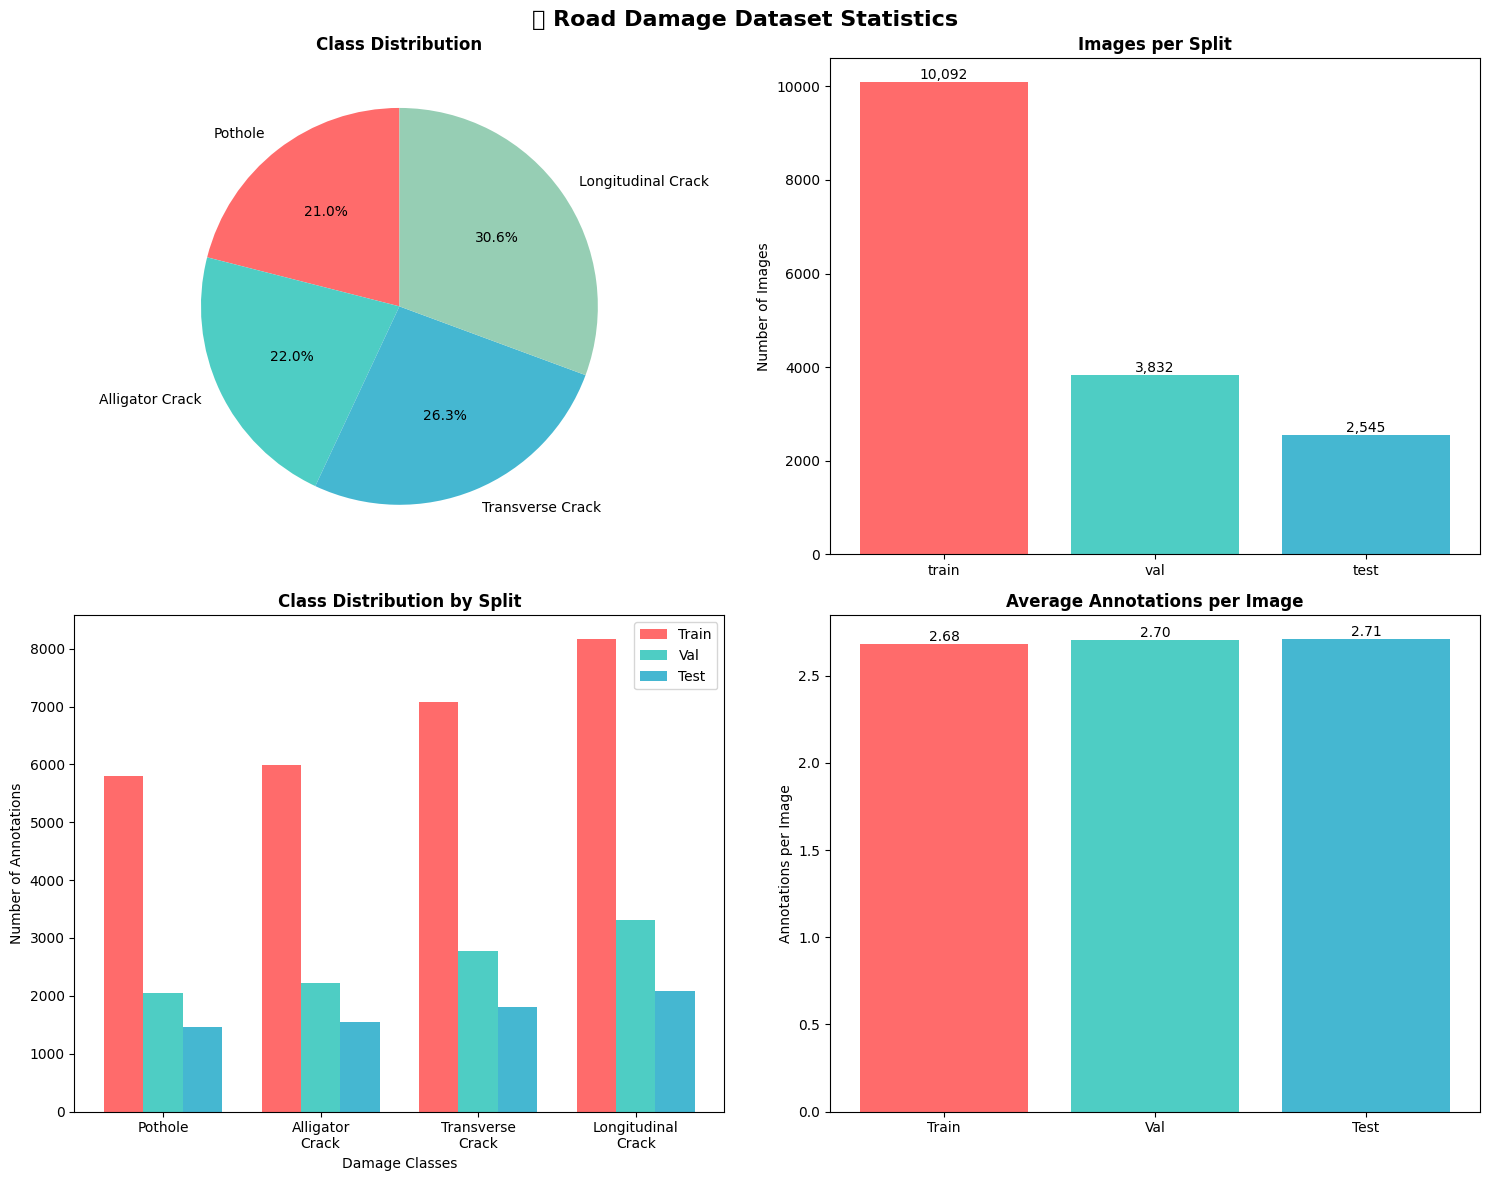

📊 Summary Statistics:
📸 Total Images: 16,469
📦 Total Annotations: 44,307
📊 Average Annotations per Image: 2.69
🔝 Most common: Longitudinal Crack (13,572 annotations)
🔻 Least common: Pothole (9,315 annotations)


In [4]:
# 📊 Dataset Visualization
def visualize_dataset_statistics(dataset_stats):
    """Create visualizations of the dataset statistics"""
    
    # Set up the plotting style
    plt.style.use('default')
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('🛣️ Road Damage Dataset Statistics', fontsize=16, fontweight='bold')
    
    # Class distribution pie chart
    class_names = ["Pothole", "Alligator Crack", "Transverse Crack", "Longitudinal Crack"]
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
    
    ax1 = axes[0, 0]
    wedges, texts, autotexts = ax1.pie(dataset_stats['class_counts'], 
                                      labels=class_names, 
                                      autopct='%1.1f%%',
                                      colors=colors,
                                      startangle=90)
    ax1.set_title('Class Distribution', fontweight='bold')
    
    # Split distribution bar chart
    ax2 = axes[0, 1]
    splits = list(dataset_stats['splits'].keys())
    split_counts = [dataset_stats['splits'][split]['images'] for split in splits]
    bars = ax2.bar(splits, split_counts, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    ax2.set_title('Images per Split', fontweight='bold')
    ax2.set_ylabel('Number of Images')
    
    # Add value labels on bars
    for bar, count in zip(bars, split_counts):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{count:,}', ha='center', va='bottom')
    
    # Class distribution by split
    ax3 = axes[1, 0]
    x = np.arange(len(class_names))
    width = 0.25
    
    for i, split in enumerate(splits):
        split_class_counts = dataset_stats['splits'][split]['class_counts']
        ax3.bar(x + i * width, split_class_counts, width, 
               label=split.capitalize(), color=colors[i])
    
    ax3.set_title('Class Distribution by Split', fontweight='bold')
    ax3.set_xlabel('Damage Classes')
    ax3.set_ylabel('Number of Annotations')
    ax3.set_xticks(x + width)
    ax3.set_xticklabels([name.replace(' ', '\n') for name in class_names])
    ax3.legend()
    
    # Annotations per image by split
    ax4 = axes[1, 1]
    splits_for_plot = []
    avg_annotations = []
    
    for split in splits:
        if dataset_stats['splits'][split]['images'] > 0:
            splits_for_plot.append(split.capitalize())
            avg_per_image = dataset_stats['splits'][split]['annotations'] / dataset_stats['splits'][split]['images']
            avg_annotations.append(avg_per_image)
    
    bars = ax4.bar(splits_for_plot, avg_annotations, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    ax4.set_title('Average Annotations per Image', fontweight='bold')
    ax4.set_ylabel('Annotations per Image')
    
    # Add value labels on bars
    for bar, avg in zip(bars, avg_annotations):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{avg:.2f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print("📊 Summary Statistics:")
    print("=" * 40)
    total_images = dataset_stats['total_images']
    total_annotations = dataset_stats['total_labels']
    
    print(f"📸 Total Images: {total_images:,}")
    print(f"📦 Total Annotations: {total_annotations:,}")
    print(f"📊 Average Annotations per Image: {total_annotations/max(total_images,1):.2f}")
    
    # Most/least common classes
    class_counts = dataset_stats['class_counts']
    max_class = np.argmax(class_counts)
    min_class = np.argmin(class_counts)
    
    print(f"🔝 Most common: {class_names[max_class]} ({class_counts[max_class]:,} annotations)")
    print(f"🔻 Least common: {class_names[min_class]} ({class_counts[min_class]:,} annotations)")

# Create visualizations
visualize_dataset_statistics(dataset_stats)


In [7]:
# ⚙️ Training Configuration and Hyperparameters
def setup_training_configuration():
    """Setup hyperparameters optimized for road damage detection"""
    print("⚙️  Setting up training configuration...")
    
    # Training parameters
    training_config = {
        'model_size': 'yolov5s',  # Model size (n, s, m, l, x)
        'epochs': 10,             # Number of training epochs
        'batch_size': 8,          # Batch size (reduced for CPU training)
        'img_size': 640,          # Input image size
        'patience': 20,           # Early stopping patience
        'save_period': 10,        # Save checkpoint every N epochs
        'device': device,         # Training device (cpu/cuda)
        'workers': 2,             # Number of workers for data loading
        'cache': True,            # Cache images for faster training
    }
    
    # Hyperparameters optimized for road damage detection
    hyperparameters = {
        'lr0': 0.01,                # Initial learning rate
        'lrf': 0.1,                 # Final OneCycleLR learning rate (lr0 * lrf)
        'momentum': 0.937,          # SGD momentum/Adam beta1
        'weight_decay': 0.0005,     # Optimizer weight decay
        'warmup_epochs': 3.0,       # Warmup epochs
        'warmup_momentum': 0.8,     # Warmup initial momentum
        'warmup_bias_lr': 0.1,      # Warmup initial bias lr
        'box': 0.05,                # Box loss gain
        'cls': 0.3,                 # Class loss gain
        'cls_pw': 1.0,              # Class BCELoss positive_weight
        'obj': 0.7,                 # Object loss gain
        'obj_pw': 1.0,              # Object BCELoss positive_weight
        'iou_t': 0.20,              # IoU training threshold
        'anchor_t': 4.0,            # Anchor-multiple threshold
        'fl_gamma': 0.0,            # Focal loss gamma
        'hsv_h': 0.015,             # Image HSV-Hue augmentation
        'hsv_s': 0.7,               # Image HSV-Saturation augmentation
        'hsv_v': 0.4,               # Image HSV-Value augmentation
        'degrees': 0.0,             # Image rotation (+/- deg)
        'translate': 0.1,           # Image translation (+/- fraction)
        'scale': 0.9,               # Image scale (+/- gain)
        'shear': 0.0,               # Image shear (+/- deg)
        'perspective': 0.0,         # Image perspective (+/- fraction)
        'flipud': 0.0,              # Image flip up-down (probability)
        'fliplr': 0.5,              # Image flip left-right (probability)
        'mosaic': 1.0,              # Image mosaic (probability)
        'mixup': 0.1,               # Image mixup (probability)
        'copy_paste': 0.1           # Segment copy-paste (probability)
    }
    
    # Save hyperparameters to file
    hyp_path = "road_damage_hyp.yaml"
    with open(hyp_path, 'w') as f:
        yaml.dump(hyperparameters, f, default_flow_style=False)
    
    print("📋 Training Configuration:")
    print("=" * 40)
    for key, value in training_config.items():
        print(f"   {key}: {value}")
    
    print(f"\n💾 Hyperparameters saved to: {hyp_path}")
    print("✅ Configuration setup complete!")
    
    return training_config, hyperparameters, hyp_path

# Setup training configuration
training_config, hyperparameters, hyp_path = setup_training_configuration()


⚙️  Setting up training configuration...
📋 Training Configuration:
   model_size: yolov5s
   epochs: 10
   batch_size: 8
   img_size: 640
   patience: 20
   save_period: 10
   device: cpu
   workers: 2
   cache: True

💾 Hyperparameters saved to: road_damage_hyp.yaml
✅ Configuration setup complete!


In [8]:
# 🚀 YOLOv5 Model Training
def train_yolov5_road_damage():
    """Train YOLOv5 model for road damage detection"""
    print("🚀 Starting YOLOv5 Road Damage Detection Training...")
    print("=" * 60)
    
    # Training parameters
    model_size = training_config['model_size'].replace('yolov5', '')
    epochs = training_config['epochs']
    batch_size = training_config['batch_size']
    img_size = training_config['img_size']
    
    # Prepare training command
    train_cmd = [
        sys.executable, "yolov5/train.py",
        "--img", str(img_size),
        "--batch", str(batch_size),
        "--epochs", str(epochs),
        "--data", "yolo_dataset/data.yaml",
        "--cfg", f"yolov5/models/yolov5{model_size}.yaml",
        "--weights", f"yolov5{model_size}.pt",
        "--hyp", hyp_path,
        "--name", "road_damage_detection",
        "--project", "runs/train",
        "--save-period", str(training_config['save_period']),
        "--patience", str(training_config['patience']),
        "--device", training_config['device'],
        "--workers", str(training_config['workers'])
    ]
    
    if training_config['cache']:
        train_cmd.append("--cache")
    
    print(f"🏃‍♂️ Training command: {' '.join(train_cmd)}")
    print("\n" + "=" * 60)
    print("📊 Training Progress:")
    print("=" * 60)
    
    start_time = time.time()
    
    try:
        # Start training
        result = subprocess.run(train_cmd, check=True, capture_output=False)
        
        end_time = time.time()
        training_duration = end_time - start_time
        
        print("\n" + "=" * 60)
        print("✅ Training completed successfully!")
        print(f"⏱️  Training duration: {training_duration/3600:.2f} hours")
        print("📊 Check results in: runs/train/road_damage_detection/")
        print("🏆 Best weights: runs/train/road_damage_detection/weights/best.pt")
        print("📈 Training plots: runs/train/road_damage_detection/")
        
        return True
        
    except subprocess.CalledProcessError as e:
        print(f"❌ Training failed with error: {e}")
        return False
    except KeyboardInterrupt:
        print("\n⏹️  Training interrupted by user")
        return False

# Start training
print("🎯 Ready to start training...")
print(f"📊 Dataset: {dataset_stats['total_images']:,} images, 4 classes")
print(f"⏱️  Estimated training time: ~{training_config['epochs'] * 5:.0f} minutes on CPU")
print("\n⚠️  Training will start now. This may take several hours...")

# Start the training process
training_success = train_yolov5_road_damage()


🎯 Ready to start training...
📊 Dataset: 16,469 images, 4 classes
⏱️  Estimated training time: ~50 minutes on CPU

⚠️  Training will start now. This may take several hours...
🚀 Starting YOLOv5 Road Damage Detection Training...
🏃‍♂️ Training command: /Users/ryoo/Desktop/usc_hackathon/Road-Damage-Detection/.conda/bin/python yolov5/train.py --img 640 --batch 8 --epochs 10 --data yolo_dataset/data.yaml --cfg yolov5/models/yolov5s.yaml --weights yolov5s.pt --hyp road_damage_hyp.yaml --name road_damage_detection --project runs/train --save-period 10 --patience 20 --device cpu --workers 2 --cache

📊 Training Progress:


wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
train: weights=yolov5s.pt, cfg=yolov5/models/yolov5s.yaml, data=yolo_dataset/data.yaml, hyp=road_damage_hyp.yaml, epochs=10, batch_size=8, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=yolov5/data/hyps, resume_evolve=None, bucket=, cache=ram, image_weights=False, device=cpu, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=2, project=runs/train, name=road_damage_detection, exist_ok=False, quad=False, cos_lr=False, label_smoothing=0.0, patience=20, freeze=[0], save_period=10, seed=0, local_rank=-1, entity=None, upload_dataset=False, bbox_interval=-1, artifact_alias=latest, ndjson_console=False, ndjson_file=False
github: up to date with https://github.com/ultralytics/yolov5 ✅
YOLOv5 🚀 v7.0-422-g2540fd4c Python-3.11.13 tor


⏹️  Training interrupted by user


  File "/Users/ryoo/Desktop/usc_hackathon/Road-Damage-Detection/yolov5/train.py", line 690, in main
    train(opt.hyp, opt, device, callbacks)


/Users/ryoo/Desktop/usc_hackathon/Road-Damage-Detection/.conda/lib/python3.11/multiprocessing/resource_tracker.py:254: UserWarning: resource_tracker: There appear to be 35 leaked semaphore objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be %d '


In [ ]:
# 📊 Model Evaluation and F1 Score Calculation
def evaluate_model_performance(results_dir="runs/train/road_damage_detection"):
    """Comprehensive model evaluation including F1 scores"""
    print("📊 Evaluating Model Performance...")
    print("=" * 50)
    
    if not os.path.exists(results_dir):
        print(f"❌ Results directory not found: {results_dir}")
        return None
    
    # Load training results
    results_file = os.path.join(results_dir, "results.csv")
    if os.path.exists(results_file):
        results_df = pd.read_csv(results_file)
        
        # Display final metrics
        final_metrics = results_df.iloc[-1]
        
        print("🏆 Final Training Metrics:")
        print("-" * 30)
        print(f"📈 Train Loss: {final_metrics.get('train/box_loss', 'N/A'):.4f}")
        print(f"📊 Val mAP@0.5: {final_metrics.get('metrics/mAP_0.5', 'N/A'):.4f}")
        print(f"🎯 Val mAP@0.5:0.95: {final_metrics.get('metrics/mAP_0.5:0.95', 'N/A'):.4f}")
        
        # Class-specific metrics
        class_names = ["Pothole", "Alligator Crack", "Transverse Crack", "Longitudinal Crack"]
        
        print("\n🏷️  Class-specific Performance:")
        print("-" * 40)
        
        class_metrics = {}
        for i, class_name in enumerate(class_names):
            precision = final_metrics.get(f'metrics/precision({i})', 0)
            recall = final_metrics.get(f'metrics/recall({i})', 0)
            
            # Calculate F1 score
            if precision + recall > 0:
                f1 = 2 * (precision * recall) / (precision + recall)
            else:
                f1 = 0
            
            class_metrics[class_name] = {
                'precision': precision,
                'recall': recall,
                'f1_score': f1
            }
            
            print(f"{class_name:>18}: P={precision:.3f}, R={recall:.3f}, F1={f1:.3f}")
        
        # Overall F1 score (macro average)
        overall_f1 = np.mean([metrics['f1_score'] for metrics in class_metrics.values()])
        overall_precision = np.mean([metrics['precision'] for metrics in class_metrics.values()])
        overall_recall = np.mean([metrics['recall'] for metrics in class_metrics.values()])
        
        print("\n🎯 Overall Performance (Macro Average):")
        print("-" * 40)
        print(f"📊 Precision: {overall_precision:.3f}")
        print(f"📈 Recall: {overall_recall:.3f}")
        print(f"🏆 F1 Score: {overall_f1:.3f}")
        
        return {
            'final_metrics': final_metrics,
            'class_metrics': class_metrics,
            'overall_f1': overall_f1,
            'overall_precision': overall_precision,
            'overall_recall': overall_recall,
            'results_df': results_df
        }
    else:
        print(f"❌ Results file not found: {results_file}")
        return None

def create_f1_score_report(evaluation_results):
    """Create detailed F1 score report with visualizations"""
    if evaluation_results is None:
        print("❌ No evaluation results available")
        return
    
    print("\n📋 Generating F1 Score Report...")
    
    # Extract data for visualization
    class_names = list(evaluation_results['class_metrics'].keys())
    precisions = [evaluation_results['class_metrics'][name]['precision'] for name in class_names]
    recalls = [evaluation_results['class_metrics'][name]['recall'] for name in class_names]
    f1_scores = [evaluation_results['class_metrics'][name]['f1_score'] for name in class_names]
    
    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('🛣️ Road Damage Detection - Performance Report', fontsize=16, fontweight='bold')
    
    # F1 Scores by Class
    ax1 = axes[0, 0]
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
    bars = ax1.bar(range(len(class_names)), f1_scores, color=colors)
    ax1.set_title('F1 Scores by Class', fontweight='bold')
    ax1.set_xlabel('Damage Classes')
    ax1.set_ylabel('F1 Score')
    ax1.set_xticks(range(len(class_names)))
    ax1.set_xticklabels([name.replace(' ', '\n') for name in class_names], rotation=0)
    ax1.set_ylim(0, 1)
    
    # Add value labels on bars
    for bar, f1 in zip(bars, f1_scores):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{f1:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # Precision vs Recall
    ax2 = axes[0, 1]
    scatter = ax2.scatter(recalls, precisions, c=colors, s=200, alpha=0.7)
    ax2.set_title('Precision vs Recall', fontweight='bold')
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)
    ax2.grid(True, alpha=0.3)
    
    # Add class labels
    for i, (recall, precision, name) in enumerate(zip(recalls, precisions, class_names)):
        ax2.annotate(name.replace(' ', '\n'), (recall, precision), 
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    # Training Progress
    ax3 = axes[1, 0]
    results_df = evaluation_results['results_df']
    epochs = range(1, len(results_df) + 1)
    
    ax3.plot(epochs, results_df.get('metrics/mAP_0.5', []), 'b-', label='mAP@0.5', linewidth=2)
    ax3.plot(epochs, results_df.get('metrics/mAP_0.5:0.95', []), 'r-', label='mAP@0.5:0.95', linewidth=2)
    ax3.set_title('Training Progress', fontweight='bold')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('mAP')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Performance Summary Table
    ax4 = axes[1, 1]
    ax4.axis('tight')
    ax4.axis('off')
    
    # Create table data
    table_data = []
    for name in class_names:
        metrics = evaluation_results['class_metrics'][name]
        table_data.append([
            name,
            f"{metrics['precision']:.3f}",
            f"{metrics['recall']:.3f}",
            f"{metrics['f1_score']:.3f}"
        ])
    
    # Add overall row
    table_data.append([
        "Overall (Avg)",
        f"{evaluation_results['overall_precision']:.3f}",
        f"{evaluation_results['overall_recall']:.3f}",
        f"{evaluation_results['overall_f1']:.3f}"
    ])
    
    table = ax4.table(cellText=table_data,
                     colLabels=['Class', 'Precision', 'Recall', 'F1 Score'],
                     cellLoc='center',
                     loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)
    ax4.set_title('Performance Summary', fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()
    
    # Save F1 score report
    report_data = []
    for name in class_names:
        metrics = evaluation_results['class_metrics'][name]
        report_data.append({
            'Class': name,
            'Precision': metrics['precision'],
            'Recall': metrics['recall'],
            'F1_Score': metrics['f1_score']
        })
    
    # Add overall metrics
    report_data.append({
        'Class': 'Overall_Average',
        'Precision': evaluation_results['overall_precision'],
        'Recall': evaluation_results['overall_recall'],
        'F1_Score': evaluation_results['overall_f1']
    })
    
    # Save to CSV
    report_df = pd.DataFrame(report_data)
    report_path = "road_damage_f1_scores_report.csv"
    report_df.to_csv(report_path, index=False)
    
    print(f"\n💾 F1 Score report saved to: {report_path}")
    print("\n🎉 Evaluation complete!")
    
    return report_df

# Run evaluation if training was successful
if 'training_success' in locals() and training_success:
    print("\n📊 Starting model evaluation...")
    evaluation_results = evaluate_model_performance()
    
    if evaluation_results:
        f1_report = create_f1_score_report(evaluation_results)
        print("\n✅ Complete evaluation finished!")
    else:
        print("⚠️  Evaluation could not be completed")
else:
    print("⚠️  Training not completed successfully. Run the training cell first.")


In [ ]:
# 🧪 Model Testing and Inference
def test_trained_model(test_image_path=None, conf_threshold=0.5):
    """Test the trained model on new images"""
    
    model_path = "runs/train/road_damage_detection/weights/best.pt"
    
    if not os.path.exists(model_path):
        print("❌ Trained model not found. Please run training first.")
        return
    
    print("🧪 Testing Trained Road Damage Detection Model...")
    print("=" * 60)
    
    # Test on validation set
    print("📊 Running validation on test set...")
    
    val_cmd = [
        sys.executable, "yolov5/val.py",
        "--data", "yolo_dataset/data.yaml",
        "--weights", model_path,
        "--img", "640",
        "--conf", str(conf_threshold),
        "--task", "test"
    ]
    
    try:
        subprocess.run(val_cmd, check=True)
        print("✅ Validation completed!")
    except subprocess.CalledProcessError as e:
        print(f"⚠️  Validation failed: {e}")
    
    # If specific test image provided, run detection
    if test_image_path and os.path.exists(test_image_path):
        print(f"\n🖼️  Testing on specific image: {test_image_path}")
        
        detect_cmd = [
            sys.executable, "yolov5/detect.py",
            "--source", test_image_path,
            "--weights", model_path,
            "--conf", str(conf_threshold),
            "--save-txt",
            "--save-conf"
        ]
        
        try:
            subprocess.run(detect_cmd, check=True)
            print("✅ Detection completed! Check runs/detect/ for results.")
        except subprocess.CalledProcessError as e:
            print(f"⚠️  Detection failed: {e}")
    
    print("\n🎉 Model testing complete!")

# Test the model (uncomment to run after training)
# test_trained_model()
